# Project 01 (basic): An MLP by hand — backpropagation in pure NumPy

**Goal:** You implement a multilayer perceptron completely yourself — the forward pass, backpropagation (the $\delta$ recursion from the script, section 1.5), gradient checking and training with minibatch SGD + momentum. No PyTorch, no sklearn model: only NumPy. Afterwards you know *exactly* what `loss.backward()` does.

**Data:** `make_moons` — two interlocking half moons. Synthetic and deliberately chosen: not linearly separable (a linear model provably fails), but 2D (we can *see* the learned decision boundary), reproducible via a seed.

Mathematical reference — the four backprop equations we implement:

$$\boldsymbol{\delta}^{(L)} = \mathbf{p} - \mathbf{y} \qquad \text{(sigmoid + BCE)}$$
$$\boldsymbol{\delta}^{(\ell)} = \big({W^{(\ell+1)}}^\top \boldsymbol{\delta}^{(\ell+1)}\big) \odot \sigma'\big(\mathbf{z}^{(\ell)}\big)$$
$$\nabla_{W^{(\ell)}} \mathcal{L} = \tfrac{1}{B}\, \boldsymbol{\delta}^{(\ell)} {\mathbf{A}^{(\ell-1)}}^\top \qquad \nabla_{\mathbf{b}^{(\ell)}} \mathcal{L} = \tfrac{1}{B} \textstyle\sum_{\text{batch}} \boldsymbol{\delta}^{(\ell)}$$

(Batch convention here: columns = examples, i.e. $\mathbf{A}^{(\ell)} \in \mathbb{R}^{d_\ell \times B}$.)

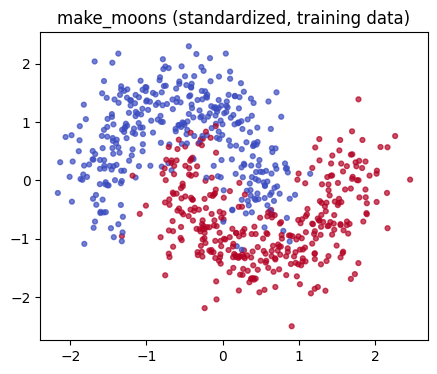

(700, 2) (300, 2)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

rng = np.random.default_rng(42)

# Data: 2 half moons, deliberately noisy (noise=0.25) so that the task is not trivial
X, y = make_moons(n_samples=1000, noise=0.25, random_state=42)
X = (X - X.mean(axis=0)) / X.std(axis=0)   # standardize (important for stable gradients)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap="coolwarm", s=12, alpha=0.7)
ax.set_title("make_moons (standardized, training data)")
plt.show()
print(X_train.shape, X_test.shape)

## Step 1: Architecture and forward pass

Network: $2 \to 32 \to 32 \to 1$, hidden layers with **ReLU**, the output a single **logit** $z$ (for stability we put the sigmoid inside the loss).

**Binary cross-entropy with logits**, numerically stable (cf. script 1.3 — never compute the sigmoid and the log separately):

$$\mathcal{L}(z, y) = \max(z, 0) - yz + \log\big(1 + e^{-\lvert z \rvert}\big)$$

*(Verifying it is worthwhile: for $z \ge 0$ and for $z < 0$ this is in each case exactly $-[y\log\sigma(z) + (1-y)\log(1-\sigma(z))]$, but without overflow.)*

**Initialization:** He ($\sigma_W^2 = 2/d_{\text{in}}$), because of ReLU — the derivation is in script 2.2.

In [2]:
def relu(z):
    return np.maximum(0.0, z)

def relu_prime(z):
    return (z > 0).astype(z.dtype)

def sigmoid(z):
    # stable: for z>=0 via 1/(1+e^-z), for z<0 via e^z/(1+e^z)
    out = np.empty_like(z)
    pos = z >= 0
    out[pos] = 1.0 / (1.0 + np.exp(-z[pos]))
    ez = np.exp(z[~pos])
    out[~pos] = ez / (1.0 + ez)
    return out

def bce_with_logits(z, y):
    # z, y: shape (1, B); returns the mean loss (a scalar)
    return np.mean(np.maximum(z, 0) - y * z + np.log1p(np.exp(-np.abs(z))))

class MLP:
    """MLP with ReLU hidden layers and 1 logit output. Columns = examples."""

    def __init__(self, layer_sizes, seed=0):
        rng = np.random.default_rng(seed)
        self.sizes = layer_sizes
        self.W, self.b = [], []
        for d_in, d_out in zip(layer_sizes[:-1], layer_sizes[1:]):
            self.W.append(rng.normal(0.0, np.sqrt(2.0 / d_in), size=(d_out, d_in)))
            self.b.append(np.zeros((d_out, 1)))

    def forward(self, A0):
        """A0: (d_0, B). Stores Zs and As for the backward pass."""
        self.Zs, self.As = [], [A0]
        A = A0
        L = len(self.W)
        for l in range(L):
            Z = self.W[l] @ A + self.b[l]
            self.Zs.append(Z)
            A = relu(Z) if l < L - 1 else Z   # last layer: the raw logit
            self.As.append(A)
        return A   # (1, B) logits

    def backward(self, y):
        """y: (1, B) with values in {0,1}. Fills self.dW, self.db (averaged over the batch)."""
        B = y.shape[1]
        L = len(self.W)
        self.dW = [None] * L
        self.db = [None] * L

        # Output layer: delta^(L) = p - y   (sigmoid+BCE, script 1.5 step 1)
        delta = sigmoid(self.Zs[-1]) - y                          # (1, B)

        for l in range(L - 1, -1, -1):
            # Parameter gradients (script 1.5 step 3), averaged over the batch
            self.dW[l] = (delta @ self.As[l].T) / B               # (d_l, d_{l-1})
            self.db[l] = delta.mean(axis=1, keepdims=True)        # (d_l, 1)
            if l > 0:
                # Recursion (script 1.5 step 2): back-project, damp with sigma'
                delta = (self.W[l].T @ delta) * relu_prime(self.Zs[l - 1])

    def loss(self, X, y):
        return bce_with_logits(self.forward(X), y)

    def predict(self, X):
        return (self.forward(X) > 0).astype(int)   # logit > 0  <=>  p > 0.5

## Step 2: Gradient checking — never trust a backprop you wrote yourself

We compare the analytical gradient with the **central difference** (error $O(\epsilon^2)$, script 1.6):

$$\frac{\partial \mathcal{L}}{\partial \theta_j} \approx \frac{\mathcal{L}(\theta + \epsilon \mathbf{e}_j) - \mathcal{L}(\theta - \epsilon \mathbf{e}_j)}{2\epsilon}$$

and measure the relative deviation $\dfrac{\lVert g_{\text{ana}} - g_{\text{num}} \rVert}{\lVert g_{\text{ana}} \rVert + \lVert g_{\text{num}} \rVert}$. In float64 with $\epsilon = 10^{-5}$ we expect $\lesssim 10^{-7}$.

One subtle point: ReLU is not differentiable at $z = 0$ — if some $z$ happens to lie *very* close to 0, the central difference can jump across the kink and the check seems to fail. With random data this practically never happens; on top of that we check on a small network, where everything is easy to survey.

In [3]:
def gradient_check(model, X, y, eps=1e-5, n_checks=60, seed=0):
    """Compares backprop gradients with central differences at random coordinates."""
    rng = np.random.default_rng(seed)
    model.forward(X)
    model.backward(y)
    ana_all, num_all = [], []
    params = [(W, dW) for W, dW in zip(model.W, model.dW)] + \
             [(b, db) for b, db in zip(model.b, model.db)]
    for theta, grad in params:
        flat_theta = theta.ravel()
        flat_grad = grad.ravel()
        for idx in rng.choice(flat_theta.size, size=min(n_checks, flat_theta.size), replace=False):
            orig = flat_theta[idx]
            flat_theta[idx] = orig + eps
            L_plus = model.loss(X, y)
            flat_theta[idx] = orig - eps
            L_minus = model.loss(X, y)
            flat_theta[idx] = orig
            num_all.append((L_plus - L_minus) / (2 * eps))
            ana_all.append(flat_grad[idx])
    ana, num = np.array(ana_all), np.array(num_all)
    rel = np.linalg.norm(ana - num) / (np.linalg.norm(ana) + np.linalg.norm(num))
    return rel

# Check on a small network in float64
Xc = rng.normal(size=(2, 20))            # (d0, B) — columns = examples!
yc = rng.integers(0, 2, size=(1, 20)).astype(float)
small = MLP([2, 5, 4, 1], seed=1)
rel_err = gradient_check(small, Xc, yc)
print(f"relative deviation: {rel_err:.2e}")
assert rel_err < 1e-7, "backprop is wrong!"
print("Gradient check passed — the backprop code is correct.")

relative deviation: 6.49e-11
Gradient check passed — the backprop code is correct.


## Step 3: Training with minibatch SGD + momentum

Update rules (script 2.1): $\mathbf{v} \leftarrow \mu \mathbf{v} + \mathbf{g}$, $\;\theta \leftarrow \theta - \eta\, \mathbf{v}$ with $\mu = 0.9$.

We log the training and test loss per epoch — the curves are the most important diagnostic instrument (overfitting? learning rate too large or too small?).

Test accuracy after training: 0.950


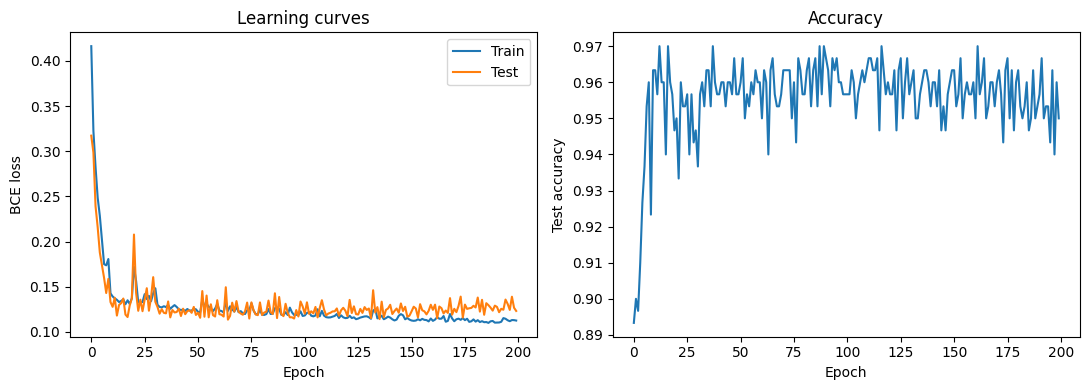

In [4]:
def train(model, X_tr, y_tr, X_te, y_te, epochs=200, batch_size=64, lr=0.1, momentum=0.9, seed=0):
    rng = np.random.default_rng(seed)
    Xtr, ytr = X_tr.T, y_tr.reshape(1, -1).astype(float)   # columns = examples
    Xte, yte = X_te.T, y_te.reshape(1, -1).astype(float)
    n = Xtr.shape[1]
    vW = [np.zeros_like(W) for W in model.W]
    vb = [np.zeros_like(b) for b in model.b]
    hist = {"train_loss": [], "test_loss": [], "test_acc": []}

    for epoch in range(epochs):
        perm = rng.permutation(n)
        for start in range(0, n, batch_size):
            idx = perm[start:start + batch_size]
            Xb, yb = Xtr[:, idx], ytr[:, idx]
            model.forward(Xb)
            model.backward(yb)
            for l in range(len(model.W)):
                vW[l] = momentum * vW[l] + model.dW[l]
                vb[l] = momentum * vb[l] + model.db[l]
                model.W[l] -= lr * vW[l]
                model.b[l] -= lr * vb[l]
        hist["train_loss"].append(model.loss(Xtr, ytr))
        hist["test_loss"].append(model.loss(Xte, yte))
        hist["test_acc"].append((model.predict(Xte) == yte).mean())
    return hist

model = MLP([2, 32, 32, 1], seed=3)
hist = train(model, X_train, y_train, X_test, y_test)
print(f"Test accuracy after training: {hist['test_acc'][-1]:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(hist["train_loss"], label="Train")
axes[0].plot(hist["test_loss"], label="Test")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("BCE loss"); axes[0].legend(); axes[0].set_title("Learning curves")
axes[1].plot(hist["test_acc"])
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Test accuracy"); axes[1].set_title("Accuracy")
plt.tight_layout(); plt.show()

## Step 4: The learned decision boundary

The actual purpose of the 2D data: we can *see* which function the network has learned. A linear model could only draw a straight line here — the MLP has composed a curved boundary out of the ReLU kinks (piecewise linear, if you look closely!).

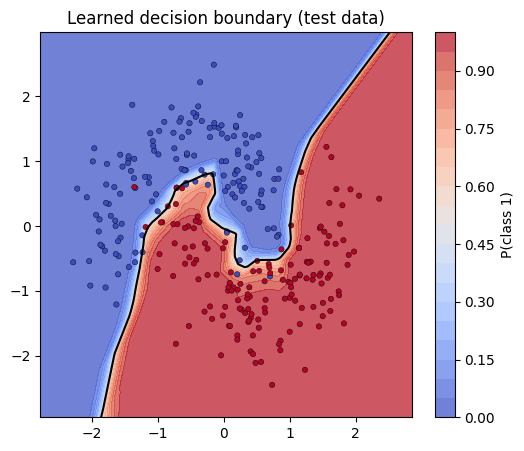

In [5]:
def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
    grid = np.c_[xx.ravel(), yy.ravel()].T                    # (2, 90000)
    probs = sigmoid(model.forward(grid)).reshape(xx.shape)
    fig, ax = plt.subplots(figsize=(6, 5))
    cs = ax.contourf(xx, yy, probs, levels=20, cmap="coolwarm", alpha=0.75)
    ax.contour(xx, yy, probs, levels=[0.5], colors="k", linewidths=1.5)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", edgecolors="k", s=15, linewidths=0.3)
    fig.colorbar(cs, label="P(class 1)")
    ax.set_title(title)
    plt.show()

plot_decision_boundary(model, X_test, y_test, "Learned decision boundary (test data)")

## Step 5: Experiment — capacity and the decision boundary

How does the width of the network change the learned function? We train three networks: underparameterized ($2{\to}2{\to}1$), moderate ($2{\to}16{\to}1$), wide ($2{\to}128{\to}128{\to}1$), and compare the boundary and the test accuracy. Watch how the 2-neuron network fails structurally (it only has 2 ReLU kinks available) and whether the wide network overfits (script 3.6: not necessarily!).

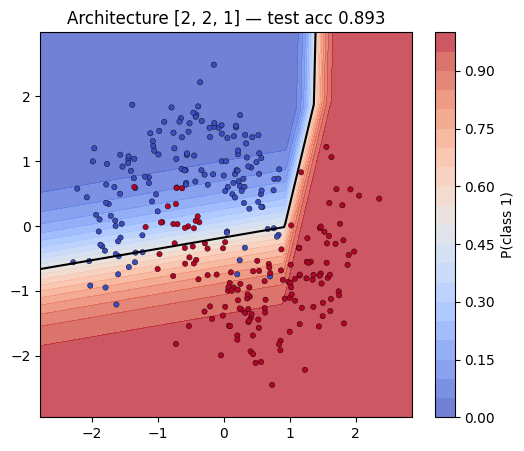

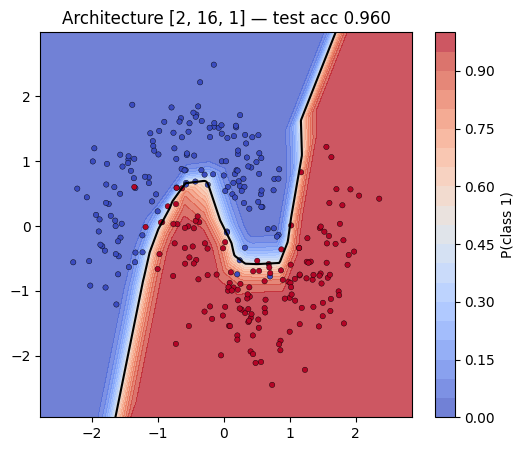

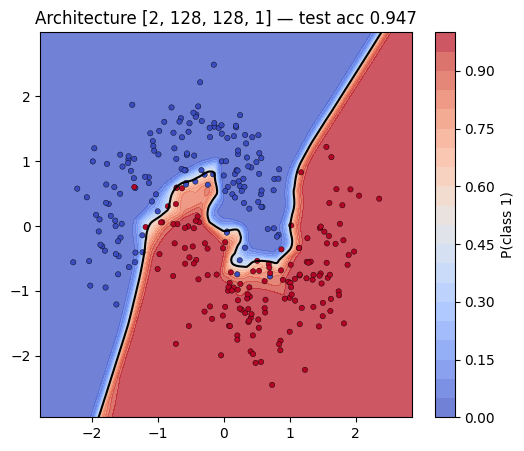

In [6]:
for sizes in [[2, 2, 1], [2, 16, 1], [2, 128, 128, 1]]:
    m = MLP(sizes, seed=3)
    h = train(m, X_train, y_train, X_test, y_test)
    plot_decision_boundary(m, X_test, y_test,
                           f"Architecture {sizes} — test acc {h['test_acc'][-1]:.3f}")

## Conclusion

- The four backprop equations from the script are the *complete* core of deep learning — everything else (Adam, BatchNorm, CNNs) is refinement around them.
- **Gradient checking** is the standard technique for verifying hand-written gradients — a relative deviation $< 10^{-7}$ in float64, or it is a bug.
- Capacity shapes the decision boundary: too small → structural underfitting; large → often good generalization anyway (double descent, script 3.6).

**On to project 02:** the same principle, but with PyTorch, real image data (Fashion-MNIST), CNNs and a systematic comparison of regularization and optimizers.